Holdout MAE (absolute backlog error)
        h1_mae   h3_mae    h6_mae
model                            
drift  27964.0  41489.0   69252.0
naive  34764.0  76700.0  144863.0

Same MAE in millions
       h1_mae  h3_mae  h6_mae
model                        
drift   0.028   0.041   0.069
naive   0.035   0.077   0.145

Forward forecast (drift)
   horizon_months   period  backlog_forecast
0               1  2026-01      7.210012e+06
1               3  2026-03      7.166275e+06
2               6  2026-06      7.100670e+06


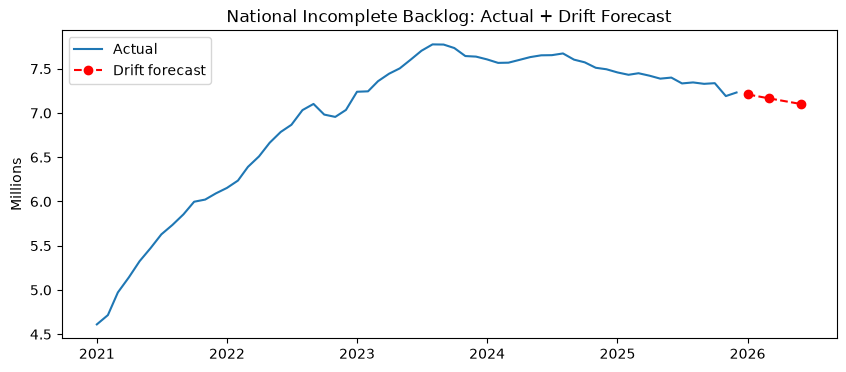

,period_yyyymm,provider_org_name,treatment_function_name,backlog,pct_within_18,gap_vs_92,pct_delta,over_52,risk_score
220318,2025-12,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,Oral Surgery Service,6534.0,21.778390,70.221610,-4.098866,681.0,82.718736
219469,2025-12,THE ROYAL WOLVERHAMPTON NHS TRUST,General Surgery Service,3753.0,30.242473,61.757527,-9.208102,240.0,78.833938
219472,2025-12,THE ROYAL WOLVERHAMPTON NHS TRUST,Ear Nose and Throat Service,5280.0,34.696970,57.303030,-12.018920,252.0,77.516531
219854,2025-12,THE PRINCESS ALEXANDRA HOSPITAL NHS TRUST,Ear Nose and Throat Service,3055.0,27.757774,64.242226,-4.131560,316.0,76.045434
219474,2025-12,THE ROYAL WOLVERHAMPTON NHS TRUST,Oral Surgery Service,4018.0,27.501244,64.498756,-2.907157,290.0,75.339431
220315,2025-12,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,Trauma and Orthopaedic Service,9497.0,28.977572,63.022428,0.029930,732.0,71.778139
218515,2025-12,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,Oral Surgery Service,6805.0,31.476855,60.523145,-2.610050,1309.0,71.570299
218569,2025-12,THE HILLINGDON HOSPITALS NHS FOUNDATION TRUST,Ear Nose and Throat Service,3844.0,28.563996,63.436004,9.118765,316.0,71.327211
218513,2025-12,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,Ear Nose and Throat Service,16004.0,35.703574,56.296426,-1.914041,1210.0,67.465030
218512,2025-12,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,Trauma and Orthopaedic Service,19124.0,35.970508,56.029492,-0.799106,3575.0,66.253417


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from src.features import load_national_series, load_trust_specialty_monthly
from src.models.forecast import (
    backtest_national_backlog,
    breach_risk_table,
    forecast_national_backlog,
)

national = load_national_series()
ts = load_trust_specialty_monthly()

# Walk-forward holdout: drift vs naive (drift won vs the old random forest)
_detail, mae_table = backtest_national_backlog(national, horizons=(1, 3, 6), n_origins=12)
print("Holdout MAE (absolute backlog error)")
print(mae_table.round(0).to_string())
print("\nSame MAE in millions")
print((mae_table / 1e6).round(3).to_string())

# National drift forecast from latest month
fc = forecast_national_backlog(national, horizons=(1, 3, 6))
print("\nForward forecast (drift)")
print(fc)

plt.figure(figsize=(10, 4))
plt.plot(national["period"], national["backlog"] / 1e6, label="Actual")
fc_dates = pd.to_datetime(fc["period"] + "-01")
plt.plot(fc_dates, fc["backlog_forecast"] / 1e6, "o--", color="red", label="Drift forecast")
plt.title("National Incomplete Backlog: Actual + Drift Forecast")
plt.ylabel("Millions")
plt.legend()
plt.show()

# Breach risk ranking
risk = breach_risk_table(ts, min_backlog=3000)
display(risk.head(15))

In [2]:
import numpy as np
import pandas as pd

from src.features import load_trust_specialty_monthly
from src.models.forecast import TARGET_PCT

MIN_BACKLOG = 3000
TOP_K = 25
N_ORIGINS = 12
RANDOM_SEED = 42


def score_month(df_month: pd.DataFrame) -> pd.DataFrame:
    """Same formula as breach_risk_table, for one calendar month."""
    now = df_month[df_month["backlog"] >= MIN_BACKLOG].copy()
    if now.empty:
        return now
    now["gap_vs_92"] = TARGET_PCT - now["pct_within_18"]
    now["risk_score"] = (
        now["gap_vs_92"].clip(lower=0)
        + 10 * np.log1p(now["backlog"]) / np.log1p(now["backlog"].max())
        + (-now["pct_delta"].fillna(0)).clip(lower=0)
    )
    return now


def pick_sets(scored: pd.DataFrame, rng: np.random.Generator) -> dict[str, pd.DataFrame]:
    k = min(TOP_K, len(scored))
    return {
        "risk_score": scored.nlargest(k, "risk_score"),
        "gap_only": scored.nlargest(k, "gap_vs_92"),
        "random": scored.sample(n=k, random_state=int(rng.integers(0, 1_000_000))),
    }


ts = load_trust_specialty_monthly().sort_values(
    ["provider_org_code", "treatment_function_code", "period"]
).copy()

keys = ["provider_org_code", "treatment_function_code"]
ts["pct_lag1"] = ts.groupby(keys)["pct_within_18"].shift(1)
ts["pct_delta"] = ts["pct_within_18"] - ts["pct_lag1"]

# Next-month outcomes joined onto each origin row
nxt = ts[keys + ["period", "pct_within_18", "over_52"]].rename(
    columns={
        "period": "next_period",
        "pct_within_18": "pct_next",
        "over_52": "over_52_next",
    }
)
ts["next_period"] = ts["period"] + pd.offsets.MonthBegin(1)
panel = ts.merge(nxt, on=keys + ["next_period"], how="inner")
panel["pct_drop"] = panel["pct_within_18"] - panel["pct_next"]
panel["over52_rise"] = panel["over_52_next"] - panel["over_52"]

periods = sorted(panel["period"].unique())
origins = periods[-(N_ORIGINS + 1) : -1]  # need a following month
rng = np.random.default_rng(RANDOM_SEED)

rows = []
for origin in origins:
    scored = score_month(panel[panel["period"] == origin])
    if len(scored) < TOP_K:
        continue
    for method, subset in pick_sets(scored, rng).items():
        rows.append({
            "origin": pd.Timestamp(origin).strftime("%Y-%m"),
            "method": method,
            "n": len(subset),
            "mean_pct_drop": subset["pct_drop"].mean(),
            "frac_pct_worse": (subset["pct_drop"] > 0).mean(),
            "mean_over52_rise": subset["over52_rise"].mean(),
            "frac_over52_worse": (subset["over52_rise"] > 0).mean(),
        })

detail = pd.DataFrame(rows)
summary = (
    detail.groupby("method", as_index=False)[
        ["mean_pct_drop", "frac_pct_worse", "mean_over52_rise", "frac_over52_worse"]
    ]
    .mean()
    .set_index("method")
    .reindex(["risk_score", "gap_only", "random"])
)

print(f"Origins: {detail['origin'].min()} → {detail['origin'].max()} "
      f"({detail['origin'].nunique()} cuts), top_k={TOP_K}, min_backlog={MIN_BACKLOG}")
print("\nAverage next-month outcomes (higher pct_drop / over52_rise = worse)")
print(summary.round(3).to_string())
print("\nPer-origin mean_pct_drop")
print(
    detail.pivot(index="origin", columns="method", values="mean_pct_drop")
    [["risk_score", "gap_only", "random"]]
    .round(2)
    .to_string()
)

Origins: 2024-11 → 2025-10 (12 cuts), top_k=25, min_backlog=3000

Average next-month outcomes (higher pct_drop / over52_rise = worse)
            mean_pct_drop  frac_pct_worse  mean_over52_rise  frac_over52_worse
method                                                                        
risk_score         -0.577           0.463             1.830              0.483
gap_only           -0.907           0.413             2.050              0.490
random             -0.221           0.480            -3.007              0.410

Per-origin mean_pct_drop
method   risk_score  gap_only  random
origin                               
2024-11       -0.19     -0.08    0.22
2024-12       -1.06     -0.68   -0.33
2025-01       -0.19     -0.58   -0.03
2025-02       -0.43     -0.92   -0.32
2025-03        0.32      0.17    0.39
2025-04       -0.72     -1.00   -0.98
2025-05       -1.52     -1.61   -0.70
2025-06        0.85      0.39    0.37
2025-07       -1.57     -2.42    0.45
2025-08       -0.42     -0.